# Rotating Vanillin Molecule GIF Generator

In [3]:
# Cell 1: Install dependencies
!pip install -q rdkit-pypi pillow numpy matplotlib
!pip install -q rdkit

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 36.7 MB/s eta 0:00:00


# Vanillin Molecule with pure black backround

In [4]:
# Cell 2: Generate vanillin

from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

# SMILES for 4-hydroxy-3-methoxybenzaldehyde (vanillin):
#  – aldehyde at C1, OH at C4 (para), OCH3 at C3 (meta)
smiles = "O=Cc1ccc(O)c(OC)c1"

mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.MMFFOptimizeMolecule(mol)

conf  = mol.GetConformer()
coords = np.array([list(conf.GetAtomPosition(i))
                   for i in range(mol.GetNumAtoms())])

In [5]:
# Cell 3: Compute ring plane & circle
rings = list(Chem.GetSymmSSSR(mol))
ring = next((r for r in rings if len(r)==6), rings[0])
idxs = list(ring)
ring_coords = coords[idxs]

center = ring_coords.mean(axis=0)
coords0 = ring_coords - center
_,_,vh = np.linalg.svd(coords0, full_matrices=False)
u1, u2 = vh[0], vh[1]
radius = np.mean(np.linalg.norm(coords0, axis=1))

theta = np.linspace(0,2*np.pi,200)
# inner dashed circle to display the resonance in the Benzene Ring
radius_inner = radius * 0.8
inner_circle = np.array([
    center + radius_inner*(np.cos(t)*u1 + np.sin(t)*u2)
    for t in theta
])
N = len(inner_circle)
dash_len = int(N * 0.12)
gap_len  = int(N * 0.06)


Run this Cell 4 if you want a pure black backround

In [7]:
# Cell 4: Render frames, assemble GIF, then display GIF

from rdkit.Chem import BondType

frames = []
offset_scale = 0.15    # spacing for the double‐bond lines
single_bond_color = 'lightgray'
double_bond_color = '#BBBBBB'  # subtle light grey to distinguish single and double bond colors
dash_color = '#FFFACD'         # pale resonance (light yellow to make it visible)

for angle in range(0, 360, 10):
    fig = plt.figure(figsize=(4,4), facecolor='black')
    ax  = fig.add_subplot(projection='3d', facecolor='black')

    # atoms by element
    element_colors = {'C':'gray','O':'red','H':'#ADD8E6'}
    atom_colors = [element_colors.get(a.GetSymbol(),'yellow')
                   for a in mol.GetAtoms()]
    ax.scatter(coords[:,0], coords[:,1], coords[:,2],
               s=100, c=atom_colors, depthshade=True)

    # bonds
    for bond in mol.GetBonds():
        i,j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        p1,p2 = coords[i], coords[j]
        xs, ys, zs = [p1[0],p2[0]], [p1[1],p2[1]], [p1[2],p2[2]]

        if bond.GetBondType() == BondType.DOUBLE:
            # compute perpendicular offset
            v = p2 - p1
            perp = np.cross(v, [0,0,1])
            if np.linalg.norm(perp) < 1e-3:
                perp = np.cross(v, [0,1,0])
            perp = perp / np.linalg.norm(perp) * offset_scale

            # first of the parallel lines
            xs1 = [p1[0]+perp[0], p2[0]+perp[0]]
            ys1 = [p1[1]+perp[1], p2[1]+perp[1]]
            zs1 = [p1[2]+perp[2], p2[2]+perp[2]]
            ax.plot(xs1, ys1, zs1,
                    color=double_bond_color,
                    linewidth=3,
                    solid_capstyle='round')

            # second parallel line
            xs2 = [p1[0]-perp[0], p2[0]-perp[0]]
            ys2 = [p1[1]-perp[1], p2[1]-perp[1]]
            zs2 = [p1[2]-perp[2], p2[2]-perp[2]]
            ax.plot(xs2, ys2, zs2,
                    color=double_bond_color,
                    linewidth=3,
                    solid_capstyle='round')
        else:
            ax.plot(xs, ys, zs,
                    color=single_bond_color,
                    linewidth=2)

    # dashed inner resonance ring at 4.5× speed
    phase = int((angle * 4.5 / 360) * N)
    for start in range(0, N, dash_len + gap_len):
        idxs = [(start + phase + k) % N for k in range(dash_len)]
        seg = inner_circle[idxs]
        ax.plot(seg[:,0], seg[:,1], seg[:,2],
                color=dash_color,
                linewidth=4)

    # camera & cleanup
    ax.view_init(elev=30, azim=angle)
    ax.set_axis_off()
    ax.dist = 7

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100,
                facecolor='black', bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    frames.append(PILImage.open(buf))

# save GIF
frames[0].save('vanillin_rotating.gif',
               format='GIF',
               save_all=True,
               append_images=frames[1:],
               duration=100,
               loop=0)

# Display result
from IPython.display import Image as DisplayImage
DisplayImage('vanillin_rotating.gif')

NameError: name 'plt' is not defined

# Vanillin Molecule with Computational Chemistry Backround

This Cell has modified code to generate the rotating Vanillin molecule, but with a "Computational Chemistry" Themed backround. (matrix like theme with building blocks of life element symbols the 'C','O','H','N','P','S' instead of ones and zeros).

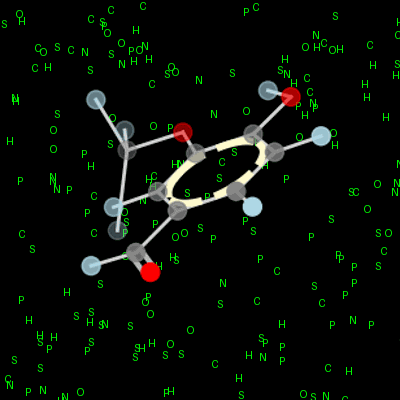

In [8]:
# Generate vanillin

from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

# SMILES for 4-hydroxy-3-methoxybenzaldehyde (vanillin):
#  – aldehyde at C1, OH at C4 (para), OCH3 at C3 (meta)
smiles = "O=Cc1ccc(O)c(OC)c1"

mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.MMFFOptimizeMolecule(mol)

conf  = mol.GetConformer()
coords = np.array([list(conf.GetAtomPosition(i))
                   for i in range(mol.GetNumAtoms())])

# Imports & molecule setup
from rdkit import Chem
from rdkit.Chem import AllChem, BondType
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage, ImageDraw, ImageFont
import io

# build & optimize vanillin
smiles = "O=Cc1ccc(O)c(OC)c1"
mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.MMFFOptimizeMolecule(mol)

# extract 3D coordinates
conf = mol.GetConformer()
coords = np.array([list(conf.GetAtomPosition(i))
                   for i in range(mol.GetNumAtoms())])

# Compute aromatic‐ring plane & resonance circle
# find a 6-member aromatic ring
rings = list(Chem.GetSymmSSSR(mol))
ring = next((r for r in rings if len(r)==6), rings[0])
ring_idxs   = list(ring)
ring_coords = coords[ring_idxs]

# PCA via SVD to get two in-plane vectors
center = ring_coords.mean(axis=0)
coords0 = ring_coords - center
_,_,vh = np.linalg.svd(coords0, full_matrices=False)
u1, u2   = vh[0], vh[1]
radius   = np.mean(np.linalg.norm(coords0, axis=1))

# build dashed‐circle points
theta    = np.linspace(0, 2*np.pi, 200)
inner_circle = np.array([
    center + radius*0.8*(np.cos(t)*u1 + np.sin(t)*u2)
    for t in theta
])
N        = len(inner_circle)
dash_len = int(N*0.12)
gap_len  = int(N*0.06)

# Generate chemistry-themed Matrix rain (40 frames)

import numpy as np
from PIL import Image as PILImage, ImageDraw, ImageFont

width, height = 400, 400
num_drops     = 200
frames_bg     = 40  # must match total molecule frames
speed_per_frame = height // frames_bg  # 400/40 = 10px per frame

# initialize drop positions and speeds
x_positions = np.random.randint(0, width, size=num_drops)
y_positions = np.random.randint(0, height, size=num_drops)
speeds       = np.full(num_drops, speed_per_frame)

# use element symbols for the “code”
chem_chars  = ['C','O','H','N','P','S']
drop_chars  = [np.random.choice(chem_chars) for _ in range(num_drops)]

# load a monospace font
try:
    font = ImageFont.truetype("DejaVuSansMono.ttf", 14)
except:
    font = ImageFont.load_default()

bg_frames = []
for f in range(frames_bg):
    img  = PILImage.new('RGBA', (width, height), 'black')
    draw = ImageDraw.Draw(img)
    for i in range(num_drops):
        x = x_positions[i]
        y = y_positions[i]
        draw.text((x, y), drop_chars[i], font=font, fill=(0,255,0,255))
        # advance & wrap
        y_positions[i] = (y + speeds[i]) % height
        # optionally change character when it wraps
        if y_positions[i] < speeds[i]:
            drop_chars[i] = np.random.choice(chem_chars)
    bg_frames.append(img)

# Render vanillin-only frames with transparent background

from rdkit.Chem import BondType
import matplotlib.pyplot as plt
import numpy as np
import io

mol_frames = []
total_frames = len(bg_frames)
angle_step   = 360 / total_frames
offset_scale = 0.15

for idx, angle in enumerate(np.arange(0, 360, angle_step)):
    # create a transparent canvas
    fig = plt.figure(figsize=(4,4), facecolor='none')
    ax  = fig.add_subplot(projection='3d', facecolor='none')

    # atoms
    element_map = {'C':'gray','O':'red','H':'#ADD8E6'}
    atom_cols   = [element_map.get(a.GetSymbol(),'yellow') for a in mol.GetAtoms()]
    ax.scatter(coords[:,0], coords[:,1], coords[:,2],
               s=100, c=atom_cols, depthshade=True)

    # bonds (single & double)
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        p1, p2 = coords[i], coords[j]
        xs, ys, zs = [p1[0],p2[0]], [p1[1],p2[1]], [p1[2],p2[2]]
        if b.GetBondType()==BondType.DOUBLE:
            v = p2-p1
            perp = np.cross(v,[0,0,1])
            if np.linalg.norm(perp)<1e-3: perp = np.cross(v,[0,1,0])
            perp = perp/np.linalg.norm(perp)*offset_scale
            for sign in (1,-1):
                xs_off = [p1[0]+sign*perp[0], p2[0]+sign*perp[0]]
                ys_off = [p1[1]+sign*perp[1], p2[1]+sign*perp[1]]
                zs_off = [p1[2]+sign*perp[2], p2[2]+sign*perp[2]]
                ax.plot(xs_off, ys_off, zs_off, color='#BBBBBB', linewidth=3, solid_capstyle='round')
        else:
            ax.plot(xs, ys, zs, color='lightgray', linewidth=2)

    # dashed resonance circle
    phase = int((angle*4/360)*N)
    for start in range(0, N, dash_len+gap_len):
        idxs = [(start+phase+k)%N for k in range(dash_len)]
        seg  = inner_circle[idxs]
        ax.plot(seg[:,0], seg[:,1], seg[:,2], color='#FFFACD', linewidth=4)

    # camera & cleanup
    ax.view_init(elev=30, azim=angle)
    ax.set_axis_off()
    ax.dist = 7

    # capture as RGBA
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100,
                transparent=True, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    mol_frames.append(PILImage.open(buf))

# Composite background + molecule frames and save GIF

frames = []
for bg_img, mol_img in zip(bg_frames, mol_frames):
    bg  = bg_img.convert('RGBA')
    mol = mol_img.convert('RGBA').resize(bg.size)
    comp = PILImage.alpha_composite(bg, mol)
    frames.append(comp)

frames[0].save(
    'vanillin_matrix_continuous_overlay.gif',
    format='GIF',
    save_all=True,
    append_images=frames[1:],
    duration=100,
    loop=0
)

from IPython.display import Image, display
display(Image('vanillin_matrix_continuous_overlay.gif'))

# Vanillin Molecule Code with matrix like backround of 1s and 0s

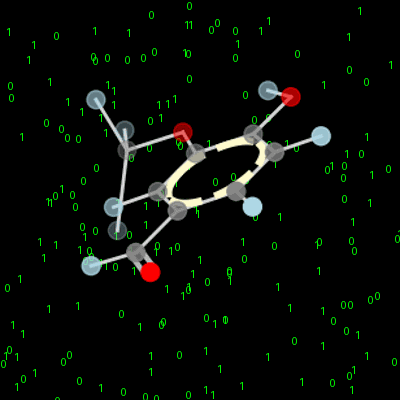

In [9]:
# Generate vanillin

from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

# SMILES for 4-hydroxy-3-methoxybenzaldehyde (vanillin):
#  – aldehyde at C1, OH at C4 (para), OCH3 at C3 (meta)
smiles = "O=Cc1ccc(O)c(OC)c1"

mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.MMFFOptimizeMolecule(mol)

conf  = mol.GetConformer()
coords = np.array([list(conf.GetAtomPosition(i))
                   for i in range(mol.GetNumAtoms())])

# Generate Binary-Rain Background (0/1 only, 40 frames)
import numpy as np
from PIL import Image as PILImage, ImageDraw, ImageFont

width, height    = 400, 400
num_drops        = 200
frames_bg_binary = 40   # must equal number of molecule frames
speed_per_frame  = height // frames_bg_binary  # 10 px per frame

x_positions = np.random.randint(0, width, size=num_drops)
y_positions = np.random.randint(0, height, size=num_drops)
speeds       = np.full(num_drops, speed_per_frame)

bin_chars   = ['0','1']
drop_chars  = [np.random.choice(bin_chars) for _ in range(num_drops)]

try:
    font = ImageFont.truetype("DejaVuSansMono.ttf", 14)
except:
    font = ImageFont.load_default()

binary_bg_frames = []
for f in range(frames_bg_binary):
    img  = PILImage.new('RGBA', (width, height), 'black')
    draw = ImageDraw.Draw(img)
    for i in range(num_drops):
        x, y = x_positions[i], y_positions[i]
        draw.text((x, y), drop_chars[i], font=font, fill=(0,255,0,255))
        y_positions[i] = (y + speeds[i]) % height
        if y_positions[i] < speeds[i]:
            drop_chars[i] = np.random.choice(bin_chars)
    binary_bg_frames.append(img)

# Composite & save under a new filename
frames = []
for bg_img, mol_img in zip(binary_bg_frames, mol_frames):
    bg   = bg_img.convert('RGBA')
    mol  = mol_img.convert('RGBA').resize(bg.size)
    comp = PILImage.alpha_composite(bg, mol)
    frames.append(comp)

frames[0].save(
    'vanillin_binary_matrix_continuous_overlay.gif',
    format='GIF',
    save_all=True,
    append_images=frames[1:],
    duration=100,
    loop=0
)

from IPython.display import Image, display
display(Image('vanillin_binary_matrix_continuous_overlay.gif'))

# Vanillin Molecule, with Computational Chemistry backround combining the previous two backrounds of the elemental symbols and the 1s and 0s

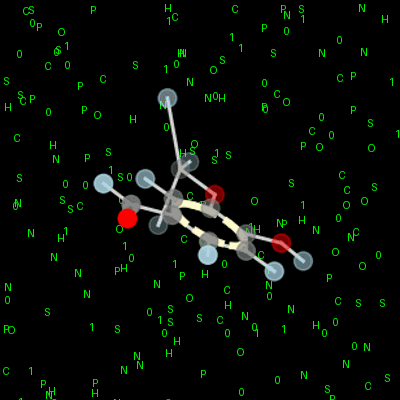

In [10]:
# ======================================================================================= #
# Rotating Vanillin over Mixed Element‐and‐Binary Rain GIF (Smooth, Zoomed‐Out, Seamless)
# ======================================================================================= #

# --- Build & optimize the vanillin molecule --- #
from rdkit import Chem
from rdkit.Chem import AllChem, BondType
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage, ImageDraw, ImageFont
import io

# SMILES for 4-hydroxy-3-methoxybenzaldehyde (vanillin):
smiles = "O=Cc1ccc(O)c(OC)c1"
mol    = Chem.AddHs(Chem.MolFromSmiles(smiles))
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.MMFFOptimizeMolecule(mol)

# Extract 3D coordinates
conf   = mol.GetConformer()
coords = np.array([list(conf.GetAtomPosition(i))
                   for i in range(mol.GetNumAtoms())])

# --- Compute benzene‐ring plane & build dashed resonance circle --- #
rings     = list(Chem.GetSymmSSSR(mol))
ring      = next((r for r in rings if len(r)==6), rings[0])
ring_idxs = list(ring)
ring_c    = coords[ring_idxs]

center  = ring_c.mean(axis=0)
coords0 = ring_c - center
_,_,vh  = np.linalg.svd(coords0, full_matrices=False)
u1, u2  = vh[0], vh[1]
radius  = np.mean(np.linalg.norm(coords0, axis=1))

theta        = np.linspace(0, 2*np.pi, 200)
inner_circle = np.array([
    center + radius*0.8*(np.cos(t)*u1 + np.sin(t)*u2)
    for t in theta
])
N        = len(inner_circle)
dash_len = int(N * 0.12)
gap_len  = int(N * 0.06)

# --- Generate seamless mixed element/binary “Matrix” rain background (80 frames) --- #
width, height       = 400, 400
num_drops           = 200
frames_bg_mixed     = 80
base_speed          = height // frames_bg_mixed   # 5 px/frame

# Give each drop a speed = base_speed × (1,2 or 3) for variation & seamless looping
speeds = base_speed * np.random.randint(1, 4, size=num_drops)

# Random initial positions
x_positions = np.random.randint(0, width, size=num_drops)
y_positions = np.random.randint(0, height, size=num_drops)

# 30% binary, 70% element symbols; characters never change for perfect looping
chem_chars = ['C','O','H','N','P','S']
bin_chars  = ['0','1']
p_bin      = 0.3
drop_chars = [
    np.random.choice(bin_chars) if np.random.rand() < p_bin else
    np.random.choice(chem_chars)
    for _ in range(num_drops)
]

# Load monospace font
try:
    font = ImageFont.truetype("DejaVuSansMono.ttf", 14)
except:
    font = ImageFont.load_default()

mixed_bg_frames = []
for _ in range(frames_bg_mixed):
    img  = PILImage.new('RGBA', (width, height), 'black')
    draw = ImageDraw.Draw(img)
    for i in range(num_drops):
        x, y = x_positions[i], y_positions[i]
        draw.text((x, y), drop_chars[i], font=font, fill=(0,255,0,255))
        # advance & wrap; exact loop after 80 frames
        y_positions[i] = (y + speeds[i]) % height
    mixed_bg_frames.append(img)

# --- Render transparent vanillin frames with manual zoom‐out & smooth rotation --- #
mol_frames   = []
angle_step   = 360 / frames_bg_mixed   # 4.5° per frame
offset_scale = 0.15

# Precompute padded bounding‐box to “zoom out”
x_min, x_max = coords[:,0].min(), coords[:,0].max()
y_min, y_max = coords[:,1].min(), coords[:,1].max()
z_min, z_max = coords[:,2].min(), coords[:,2].max()
pad          = 1.3
x_mid, y_mid, z_mid = (x_min+x_max)/2, (y_min+y_max)/2, (z_min+z_max)/2
xr = (x_max - x_min)/2 * pad
yr = (y_max - y_min)/2 * pad
zr = (z_max - z_min)/2 * pad

for idx, angle in enumerate(np.arange(0, 360, angle_step)):
    fig = plt.figure(figsize=(4,4), facecolor='none')
    ax  = fig.add_subplot(projection='3d', facecolor='none')

    # Plot atoms
    element_map = {'C':'gray','O':'red','H':'#ADD8E6'}
    atom_cols   = [element_map.get(a.GetSymbol(),'yellow') for a in mol.GetAtoms()]
    ax.scatter(coords[:,0], coords[:,1], coords[:,2],
               s=100, c=atom_cols, depthshade=True)

    # Plot bonds (single & double)
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        p1, p2 = coords[i], coords[j]
        xs, ys, zs = [p1[0],p2[0]], [p1[1],p2[1]], [p1[2],p2[2]]
        if b.GetBondType() == BondType.DOUBLE:
            v    = p2 - p1
            perp = np.cross(v, [0,0,1])
            if np.linalg.norm(perp) < 1e-3:
                perp = np.cross(v, [0,1,0])
            perp = perp / np.linalg.norm(perp) * offset_scale
            for sign in (1, -1):
                xs_off = [p1[0]+sign*perp[0], p2[0]+sign*perp[0]]
                ys_off = [p1[1]+sign*perp[1], p2[1]+sign*perp[1]]
                zs_off = [p1[2]+sign*perp[2], p2[2]+sign*perp[2]]
                ax.plot(xs_off, ys_off, zs_off,
                        color='#BBBBBB', linewidth=3, solid_capstyle='round')
        else:
            ax.plot(xs, ys, zs, color='lightgray', linewidth=2)

    # Fast dashed resonance circle
    phase = int((angle * 4.5 / 360) * N)
    for start in range(0, N, dash_len + gap_len):
        idxs = [(start + phase + k) % N for k in range(dash_len)]
        seg  = inner_circle[idxs]
        ax.plot(seg[:,0], seg[:,1], seg[:,2], color='#FFFACD', linewidth=4)

    # 4.4) Camera & manual zoom‐out
    ax.view_init(elev=30, azim=angle)
    ax.set_axis_off()
    ax.set_xlim(x_mid - xr, x_mid + xr)
    ax.set_ylim(y_mid - yr, y_mid + yr)
    ax.set_zlim(z_mid - zr, z_mid + zr)

    # capture transparent frame
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100,
                transparent=True, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    mol_frames.append(PILImage.open(buf))

# --- 5) Composite & save the final smooth GIF --- #
from IPython.display import Image, display

frames = []
for bg, mol in zip(mixed_bg_frames, mol_frames):
    comp = PILImage.alpha_composite(
        bg.convert('RGBA'),
        mol.convert('RGBA').resize((width, height))
    )
    frames.append(comp)

frames[0].save(
    'vanillin_mixed_matrix_smooth.gif',
    format='GIF',
    save_all=True,
    append_images=frames[1:],
    duration=50,   # 20 FPS for fluid motion
    loop=0
)

display(Image(filename='vanillin_mixed_matrix_smooth.gif'))

In [11]:
# To download the above GIF
import os
from google.colab import files
# Rename the file
os.rename(
    'vanillin_mixed_matrix_smooth.gif',
    'rotating_vanillin_with_computational_chemistry_background.gif'
)
files.download('rotating_vanillin_with_computational_chemistry_background.gif')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Rotating Uranocene Molecule with a Neural Network Background

This builds a uranocene U(C8H8)2 gif

The uranium is green, the carbons are black, the hydrogens are white, and the maroon rods are the uranium to ring. The background is a small neural network whose nodes drift on looping orbits and link up whenever they pass close to each other.

It sits on a light background on purpose, so it can be the light mode partner to the dark vanillin gif using the prefers-color-scheme picture trick. To make it dark instead, set bg_color near the top of the cell to a dark hex such as #0d1117.

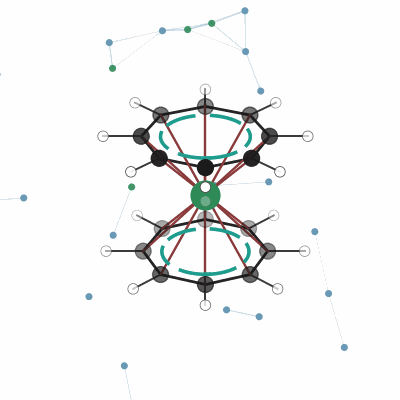

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import io

rng = np.random.default_rng(7)

width, height = 400, 400
n_frames = 80
angle_step = 360 / n_frames
elev = 30
duration = 50

bg_color = "#ffffff"

# uranium green, carbons black, hydrogens white with a soft edge so they read on the light background
u_color = "#2e8b57"
c_color = "#1a1a1a"
h_color = "#ffffff"
h_edge = "#444444"
ring_bond_color = "#222222"
ch_bond_color = "#3a3a3a"
uc_bond_color = "#8b3a3a"
reson_color = "#1f9e8f"

# real uranocene geometry by hand, two flat aromatic rings with uranium between them, eclipsed sandwich
cc = 1.40
R = cc / (2 * np.sin(np.pi / 8))         # how far each carbon sits from its ring center
d = 1.92                                 # distance from uranium up to each ring center
ch = 1.09                                # hydrogens point straight out in the ring plane
RH = R + ch
angles8 = np.arange(8) * (2 * np.pi / 8)

def ring(z):
    cs = np.stack([R * np.cos(angles8), R * np.sin(angles8), np.full(8, z)], axis=1)
    hs = np.stack([RH * np.cos(angles8), RH * np.sin(angles8), np.full(8, z)], axis=1)
    return cs, hs

C_top, H_top = ring(+d)
C_bot, H_bot = ring(-d)
U = np.array([[0.0, 0.0, 0.0]])
C_all = np.vstack([C_top, C_bot])
H_all = np.vstack([H_top, H_bot])

# one resonance circle per ring, lying flat inside it
theta = np.linspace(0, 2 * np.pi, 200)
def reson_circle(z):
    r = R * 0.70
    return np.stack([r * np.cos(theta), r * np.sin(theta), np.full(len(theta), z)], axis=1)
reson_top = reson_circle(+d)
reson_bot = reson_circle(-d)
Nr = len(theta)
dash_len = int(Nr * 0.12)
gap_len = int(Nr * 0.06)

# a fixed cube around the molecule so it keeps its real proportions and does not change size as it turns
L = RH * 1.18

# neural network background. each node rides a small looping orbit so the whole thing repeats exactly after 80 frames
n_nodes = 26
nb_base = rng.uniform(0, width, size=(n_nodes, 2))
nb_amp = rng.uniform(12, 42, size=(n_nodes, 2))
nb_freq = rng.integers(1, 3, size=(n_nodes, 2)).astype(float)
nb_phase = rng.uniform(0, 2 * np.pi, size=(n_nodes, 2))
node_palette = np.array(["#5b8fb0"] * n_nodes)
node_palette[rng.choice(n_nodes, size=5, replace=False)] = "#2e8b57"   # a few green nodes cause I like green
edge_thresh = 95.0

def node_positions(t):
    ph = 2 * np.pi * nb_freq * (t / n_frames) + nb_phase
    return nb_base + nb_amp * np.sin(ph)

def render_bg(t):
    fig = plt.figure(figsize=(4, 4), dpi=100)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, width); ax.set_ylim(0, height)
    ax.axis("off")
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)
    pos = node_positions(t)
    # connect any two nodes that have drifted close, fading the line out with distance
    for a in range(n_nodes):
        for b in range(a + 1, n_nodes):
            dist = np.hypot(*(pos[a] - pos[b]))
            if dist < edge_thresh:
                alpha = (1 - dist / edge_thresh) * 0.5
                ax.plot([pos[a, 0], pos[b, 0]], [pos[a, 1], pos[b, 1]],
                        color="#6f9ec0", alpha=alpha, linewidth=1.0)
    ax.scatter(pos[:, 0], pos[:, 1], s=26, c=node_palette, alpha=0.9, edgecolors="none", zorder=3)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", facecolor=bg_color)
    plt.close(fig)
    buf.seek(0)
    return PILImage.open(buf).convert("RGBA").resize((width, height))

def render_mol(angle):
    fig = plt.figure(figsize=(4, 4), dpi=100)
    ax = fig.add_subplot(111, projection="3d")
    ax.set_position([0, 0, 1, 1])

    # draw the bonds first so the atom balls land on top of them
    for k in range(8):
        kn = (k + 1) % 8
        for Cs in (C_top, C_bot):
            ax.plot(*zip(Cs[k], Cs[kn]), color=ring_bond_color, linewidth=2)
    for Cs, Hs in ((C_top, H_top), (C_bot, H_bot)):
        for k in range(8):
            ax.plot(*zip(Cs[k], Hs[k]), color=ch_bond_color, linewidth=1.4)
    for Cs in (C_top, C_bot):
        for k in range(8):
            ax.plot(*zip(U[0], Cs[k]), color=uc_bond_color, linewidth=1.7)

    # resonance dashes chase around each ring at the same rate as the vanillin
    phase = int((angle * 4.5 / 360) * Nr) % Nr
    for circ in (reson_top, reson_bot):
        for start in range(0, Nr, dash_len + gap_len):
            idxs = [(start + phase + m) % Nr for m in range(dash_len)]
            seg = circ[idxs]
            ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], color=reson_color, linewidth=2.6)

    ax.scatter(C_all[:, 0], C_all[:, 1], C_all[:, 2], s=130, c=c_color, depthshade=True)
    ax.scatter(H_all[:, 0], H_all[:, 1], H_all[:, 2], s=58, c=h_color,
               edgecolors=h_edge, linewidths=0.6, depthshade=True)
    ax.scatter(U[:, 0], U[:, 1], U[:, 2], s=430, c=u_color, depthshade=True)

    ax.view_init(elev=elev, azim=angle)
    ax.set_axis_off()
    ax.set_xlim(-L, L); ax.set_ylim(-L, L); ax.set_zlim(-L, L)
    ax.set_box_aspect([1, 1, 1])

    buf = io.BytesIO()
    fig.savefig(buf, format="png", transparent=True)
    plt.close(fig)
    buf.seek(0)
    return PILImage.open(buf).convert("RGBA").resize((width, height))

frames = []
for idx, angle in enumerate(np.arange(0, 360, angle_step)):
    bg = render_bg(idx)
    mol = render_mol(angle)
    frames.append(PILImage.alpha_composite(bg, mol))

frames[0].save("rotating_uranocene_with_neural_network_background.gif",
               format="GIF", save_all=True, append_images=frames[1:],
               duration=duration, loop=0)

from IPython.display import Image as DisplayImage
DisplayImage("rotating_uranocene_with_neural_network_background.gif")

In [13]:
# download the finished gif
from google.colab import files
files.download("rotating_uranocene_with_neural_network_background.gif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>